# Historical Price Analysis

This notebook is now a presentation layer for the reusable workflow in `main.py`. The code cells below call functions from `main.py`, display the key results, and write all requested CSV and image outputs to the `outputs` directory.

### Reproducibility
To regenerate every output without using the notebook, run `python main.py` from the project directory. The notebook and script use the same functions, so the displayed results and saved files stay aligned.

In [53]:
# import required libraries
from IPython.display import Image, display
import importlib
import pandas as pd
import main

importlib.reload(main)

# import all functions from main.py
from main import (
    save_dataframe,
    compute_hourly_shape_profiles,
    compute_hourly_volatility,
    compute_max_volatility_by_year,
    compute_monthly_average_prices,
    export_daily_price_files,
    load_historical_prices,
    monthly_average_price_plots,
    save_open_ended_analysis_plots,
    yearly_volatility_plots,
)

### Task 1: Load Historical Prices

The historical CSV files are loaded and combined into one dataframe. The loader validates the required columns, parses timestamps, and keeps the source filename for traceability.

In [54]:
combined_df = load_historical_prices()

print(f"Rows loaded: {len(combined_df):,}")
print(f"Settlement points: {combined_df['SettlementPoint'].nunique()}")
print(f"Date range: {combined_df['Date'].min()} to {combined_df['Date'].max()}")

Rows loaded: 497,320
Settlement points: 15
Date range: 2016-01-01 00:00:00 to 2019-12-31 23:00:00


### Task 2 & 3: Monthly Average Prices

Monthly average prices are computed by settlement point and year-month for all hubs and load zones. The resulting CSV is written to `outputs/AveragePriceByMonth.csv`.

In [55]:
monthly_avg = compute_monthly_average_prices(combined_df)
average_price_csv = save_dataframe(monthly_avg, "AveragePriceByMonth", ["SettlementPoint", "Year", "Month", "AveragePrice"])


### Task 4 & 5: Hourly Volatility

Hourly volatility is the standard deviation of hourly log returns. The calculation uses settlement hubs only (`HB_`) and filters out zero or negative prices before taking logarithms.

In [56]:
volatility = compute_hourly_volatility(combined_df)
hourly_volatility_csv = save_dataframe(volatility, "HourlyVolatilityByYear")


### Task 6: Highest Volatility By Year

In [57]:
max_vol_by_year = compute_max_volatility_by_year(volatility)
max_volatility_csv = save_dataframe(max_vol_by_year, "MaxVolatilityByYear")


### Task 7: Data Translation and Formatting into cQuant format

In [58]:
daily_price_files = export_daily_price_files(combined_df)

### Bonus Tasks

#### Bonus – Mean Plots 

Settlement hub and load zone prices generally move closely together, which suggests that market conditions were the main driver rather than individual location effects. 

The major spikes in 2018 and especially August 2019 were mainly caused by very tight supply-demand conditions during hot summer periods: high temperatures pushed electricity demand up sharply, while available reserve margins were limited; in 2019, low wind output during peak demand hours and scarcity pricing lifted monthly averages across almost all hubs and zones. 

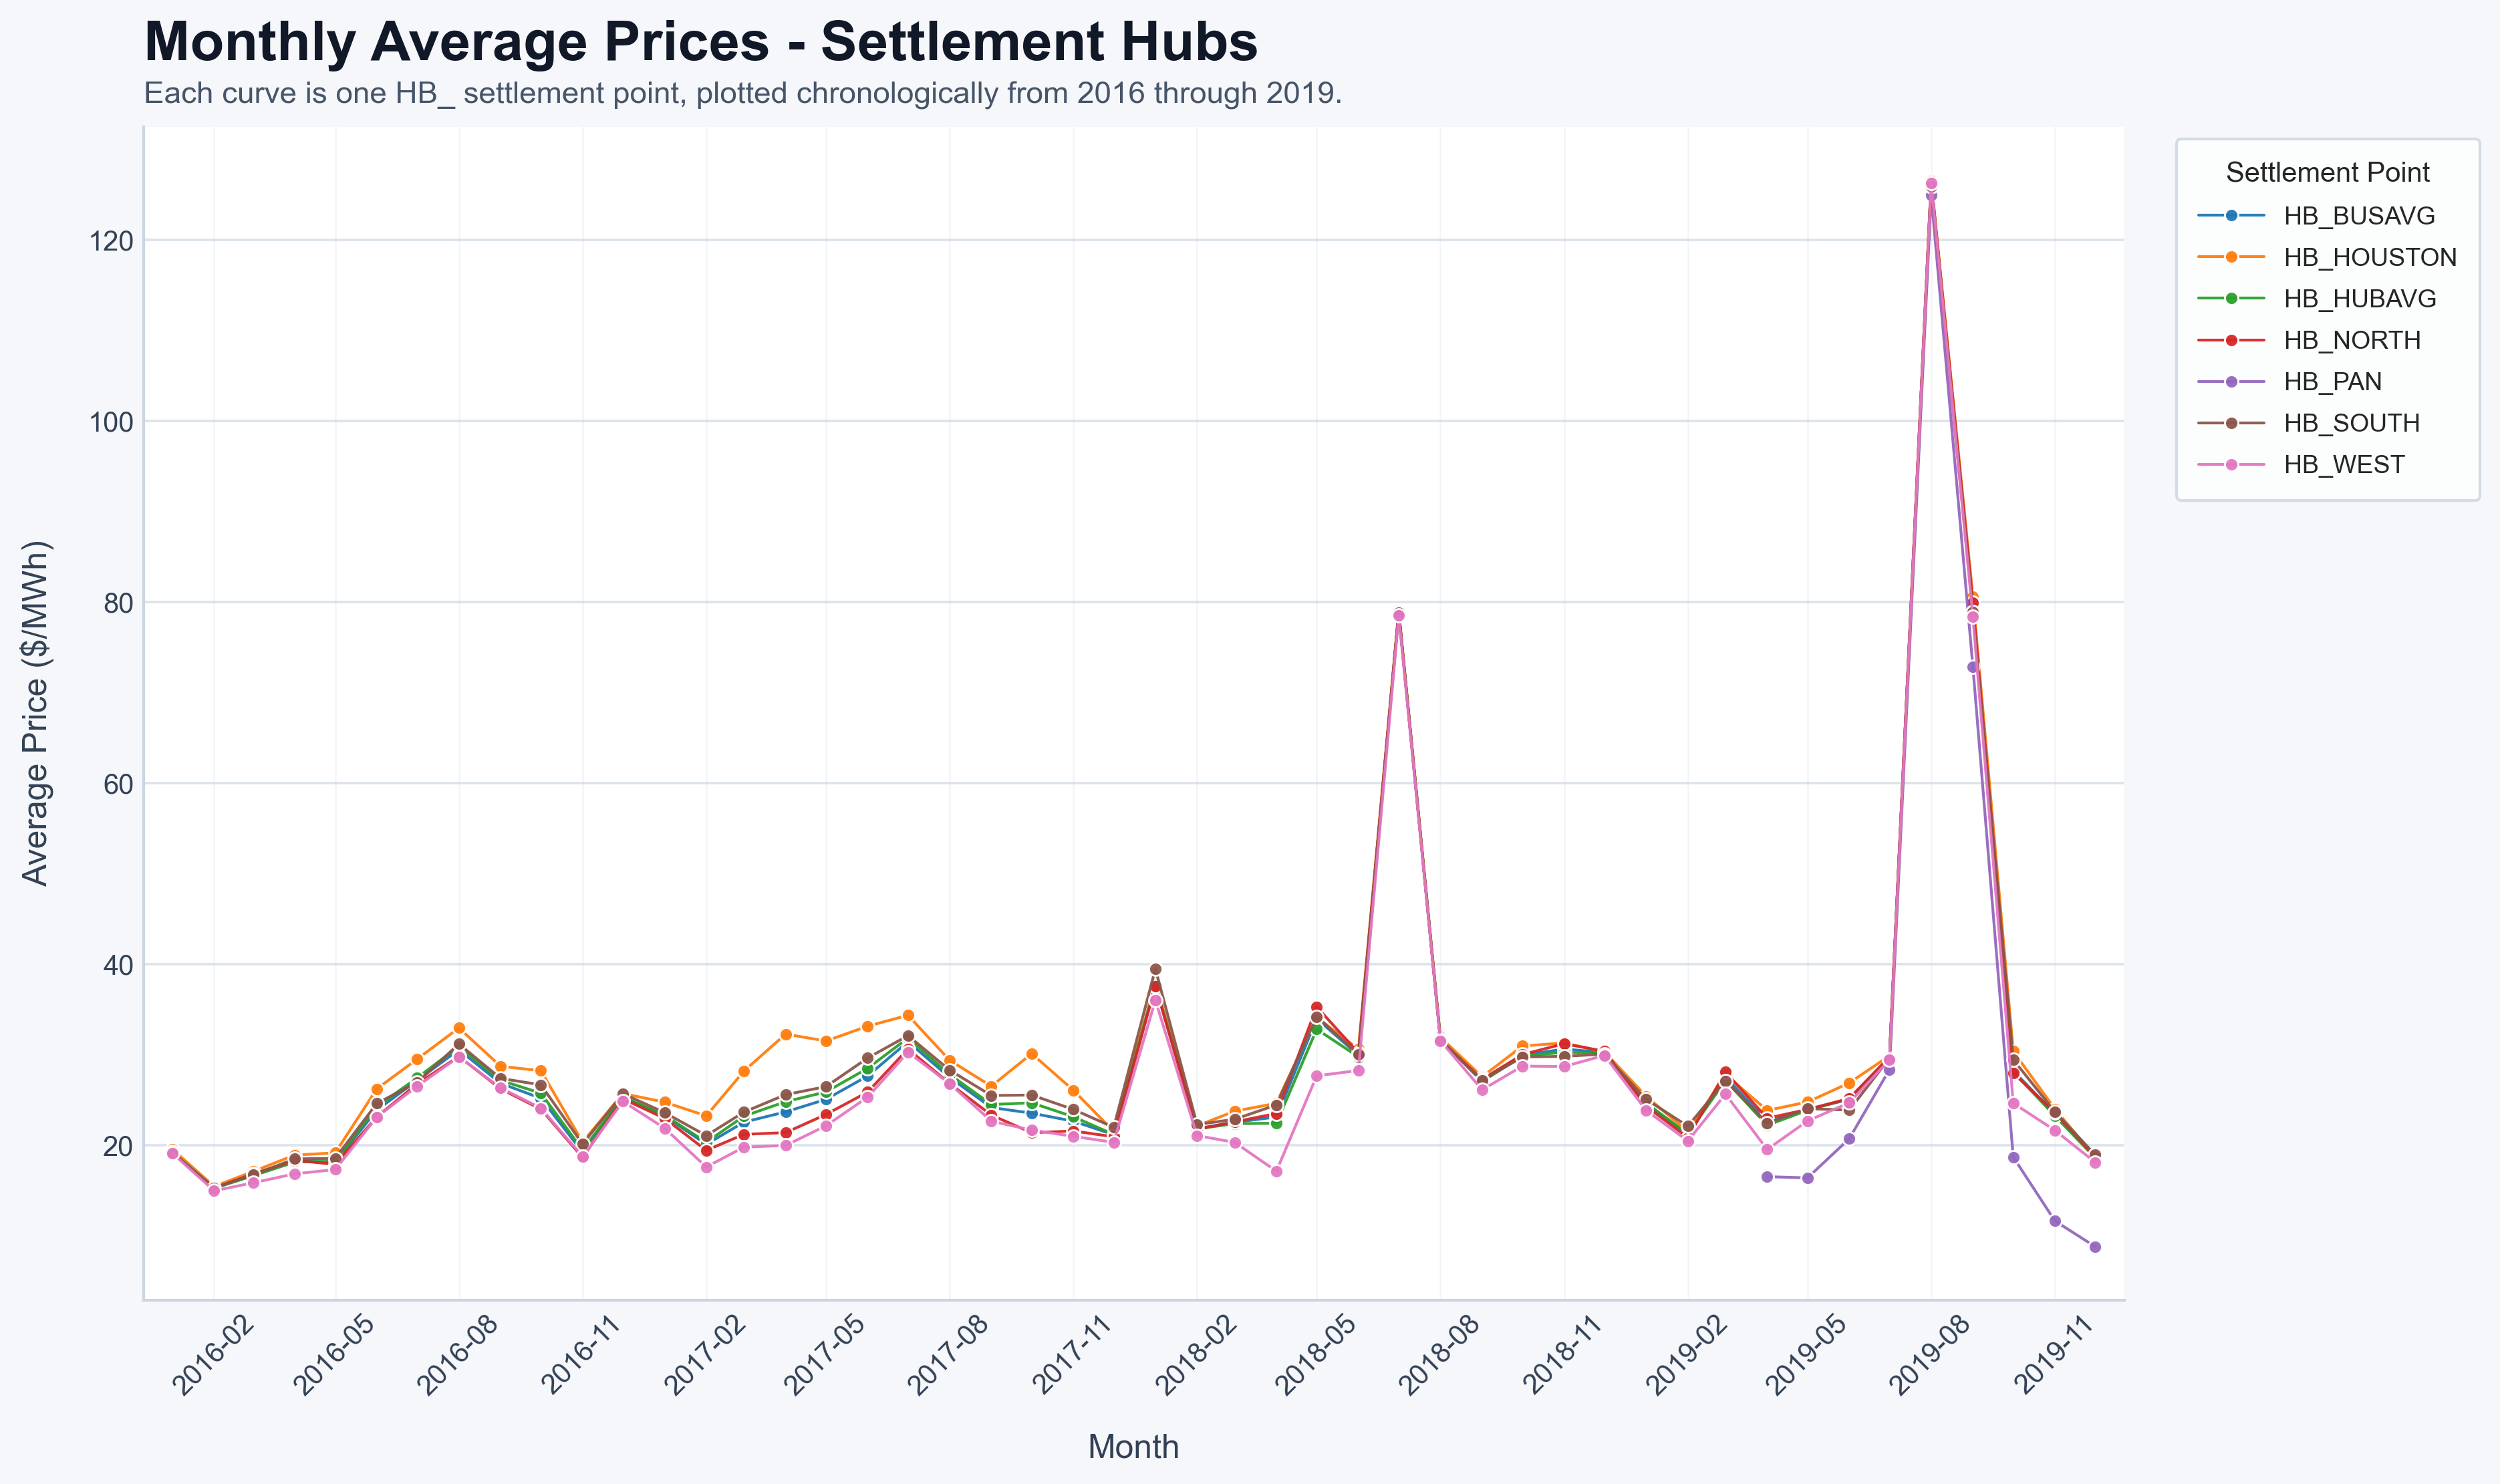

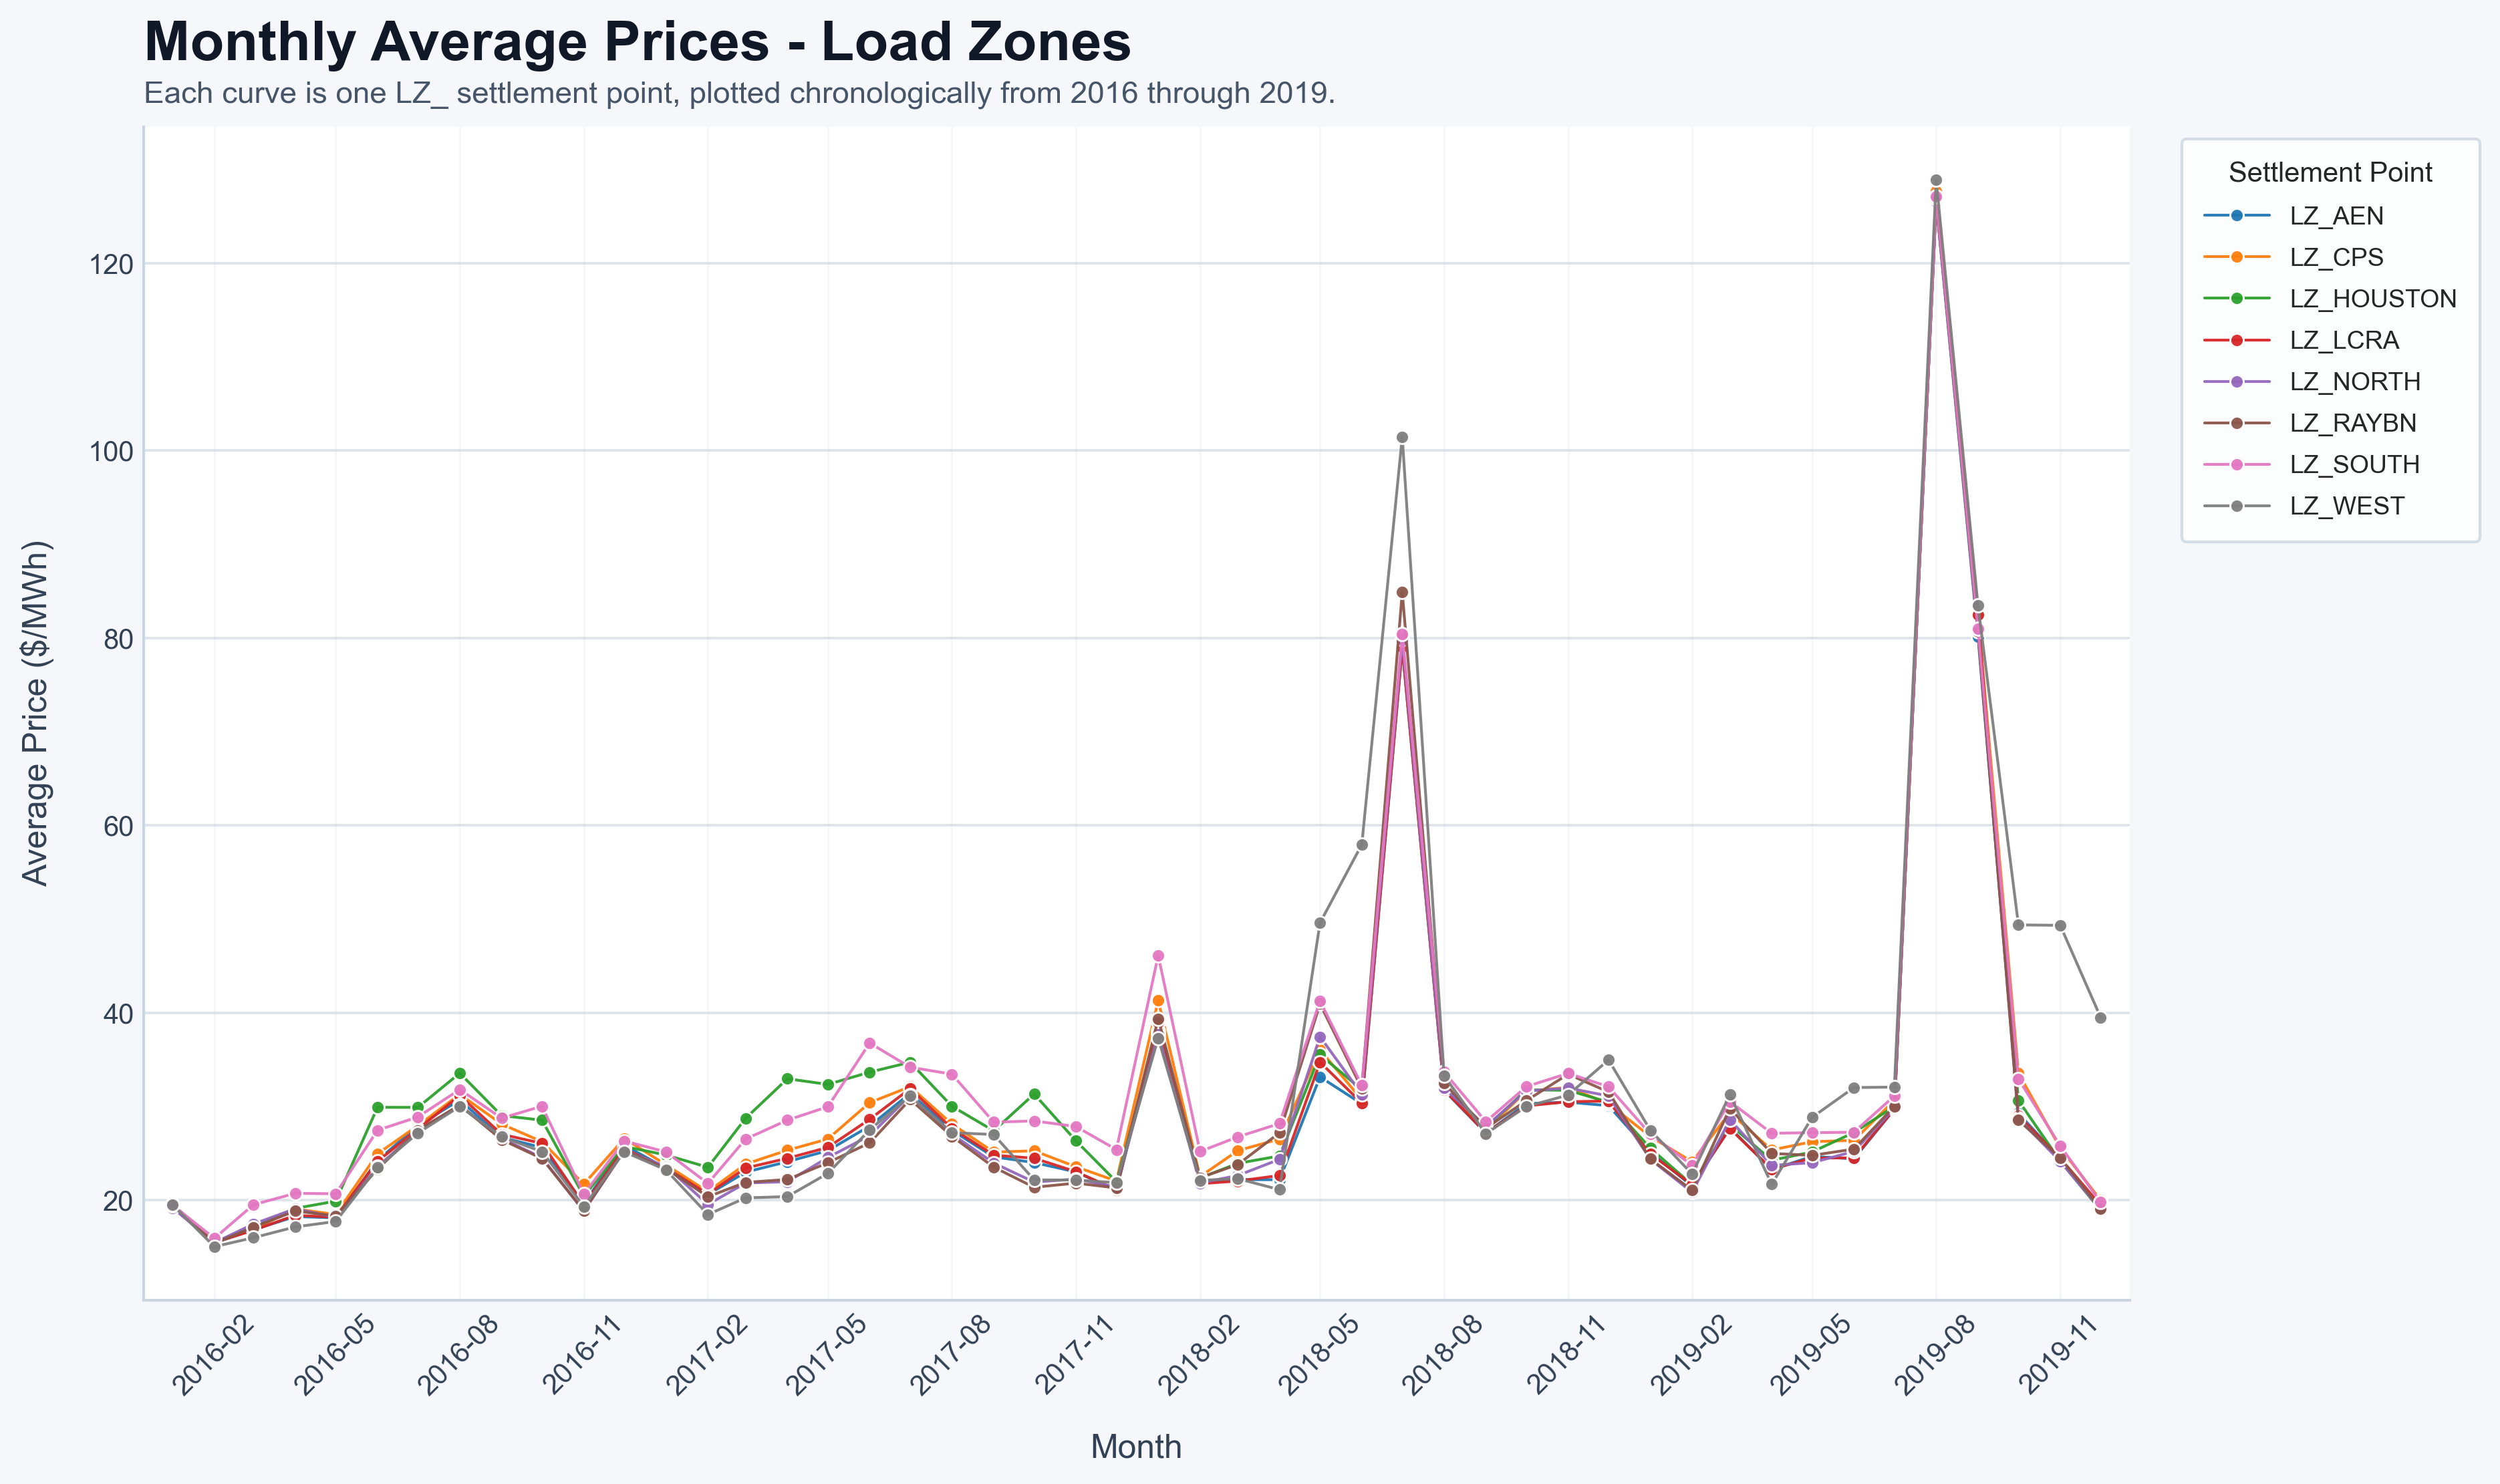

In [59]:
monthly_plot_paths = monthly_average_price_plots(monthly_avg)
display(Image(filename=str(monthly_plot_paths['hub_plot'])))
display(Image(filename=str(monthly_plot_paths['load_zone_plot'])))

#### Bonus – Volatility Plots

Hourly price volatility was relatively stable across most settlement hubs between 2016–2019. However, HB_WEST exhibited consistently higher volatility that increased over time, while HB_PAN experienced an exceptionally high volatility of 0.632 in 2019, indicating much larger and more frequent price swings, likely driven by localized congestion or extreme market conditions.

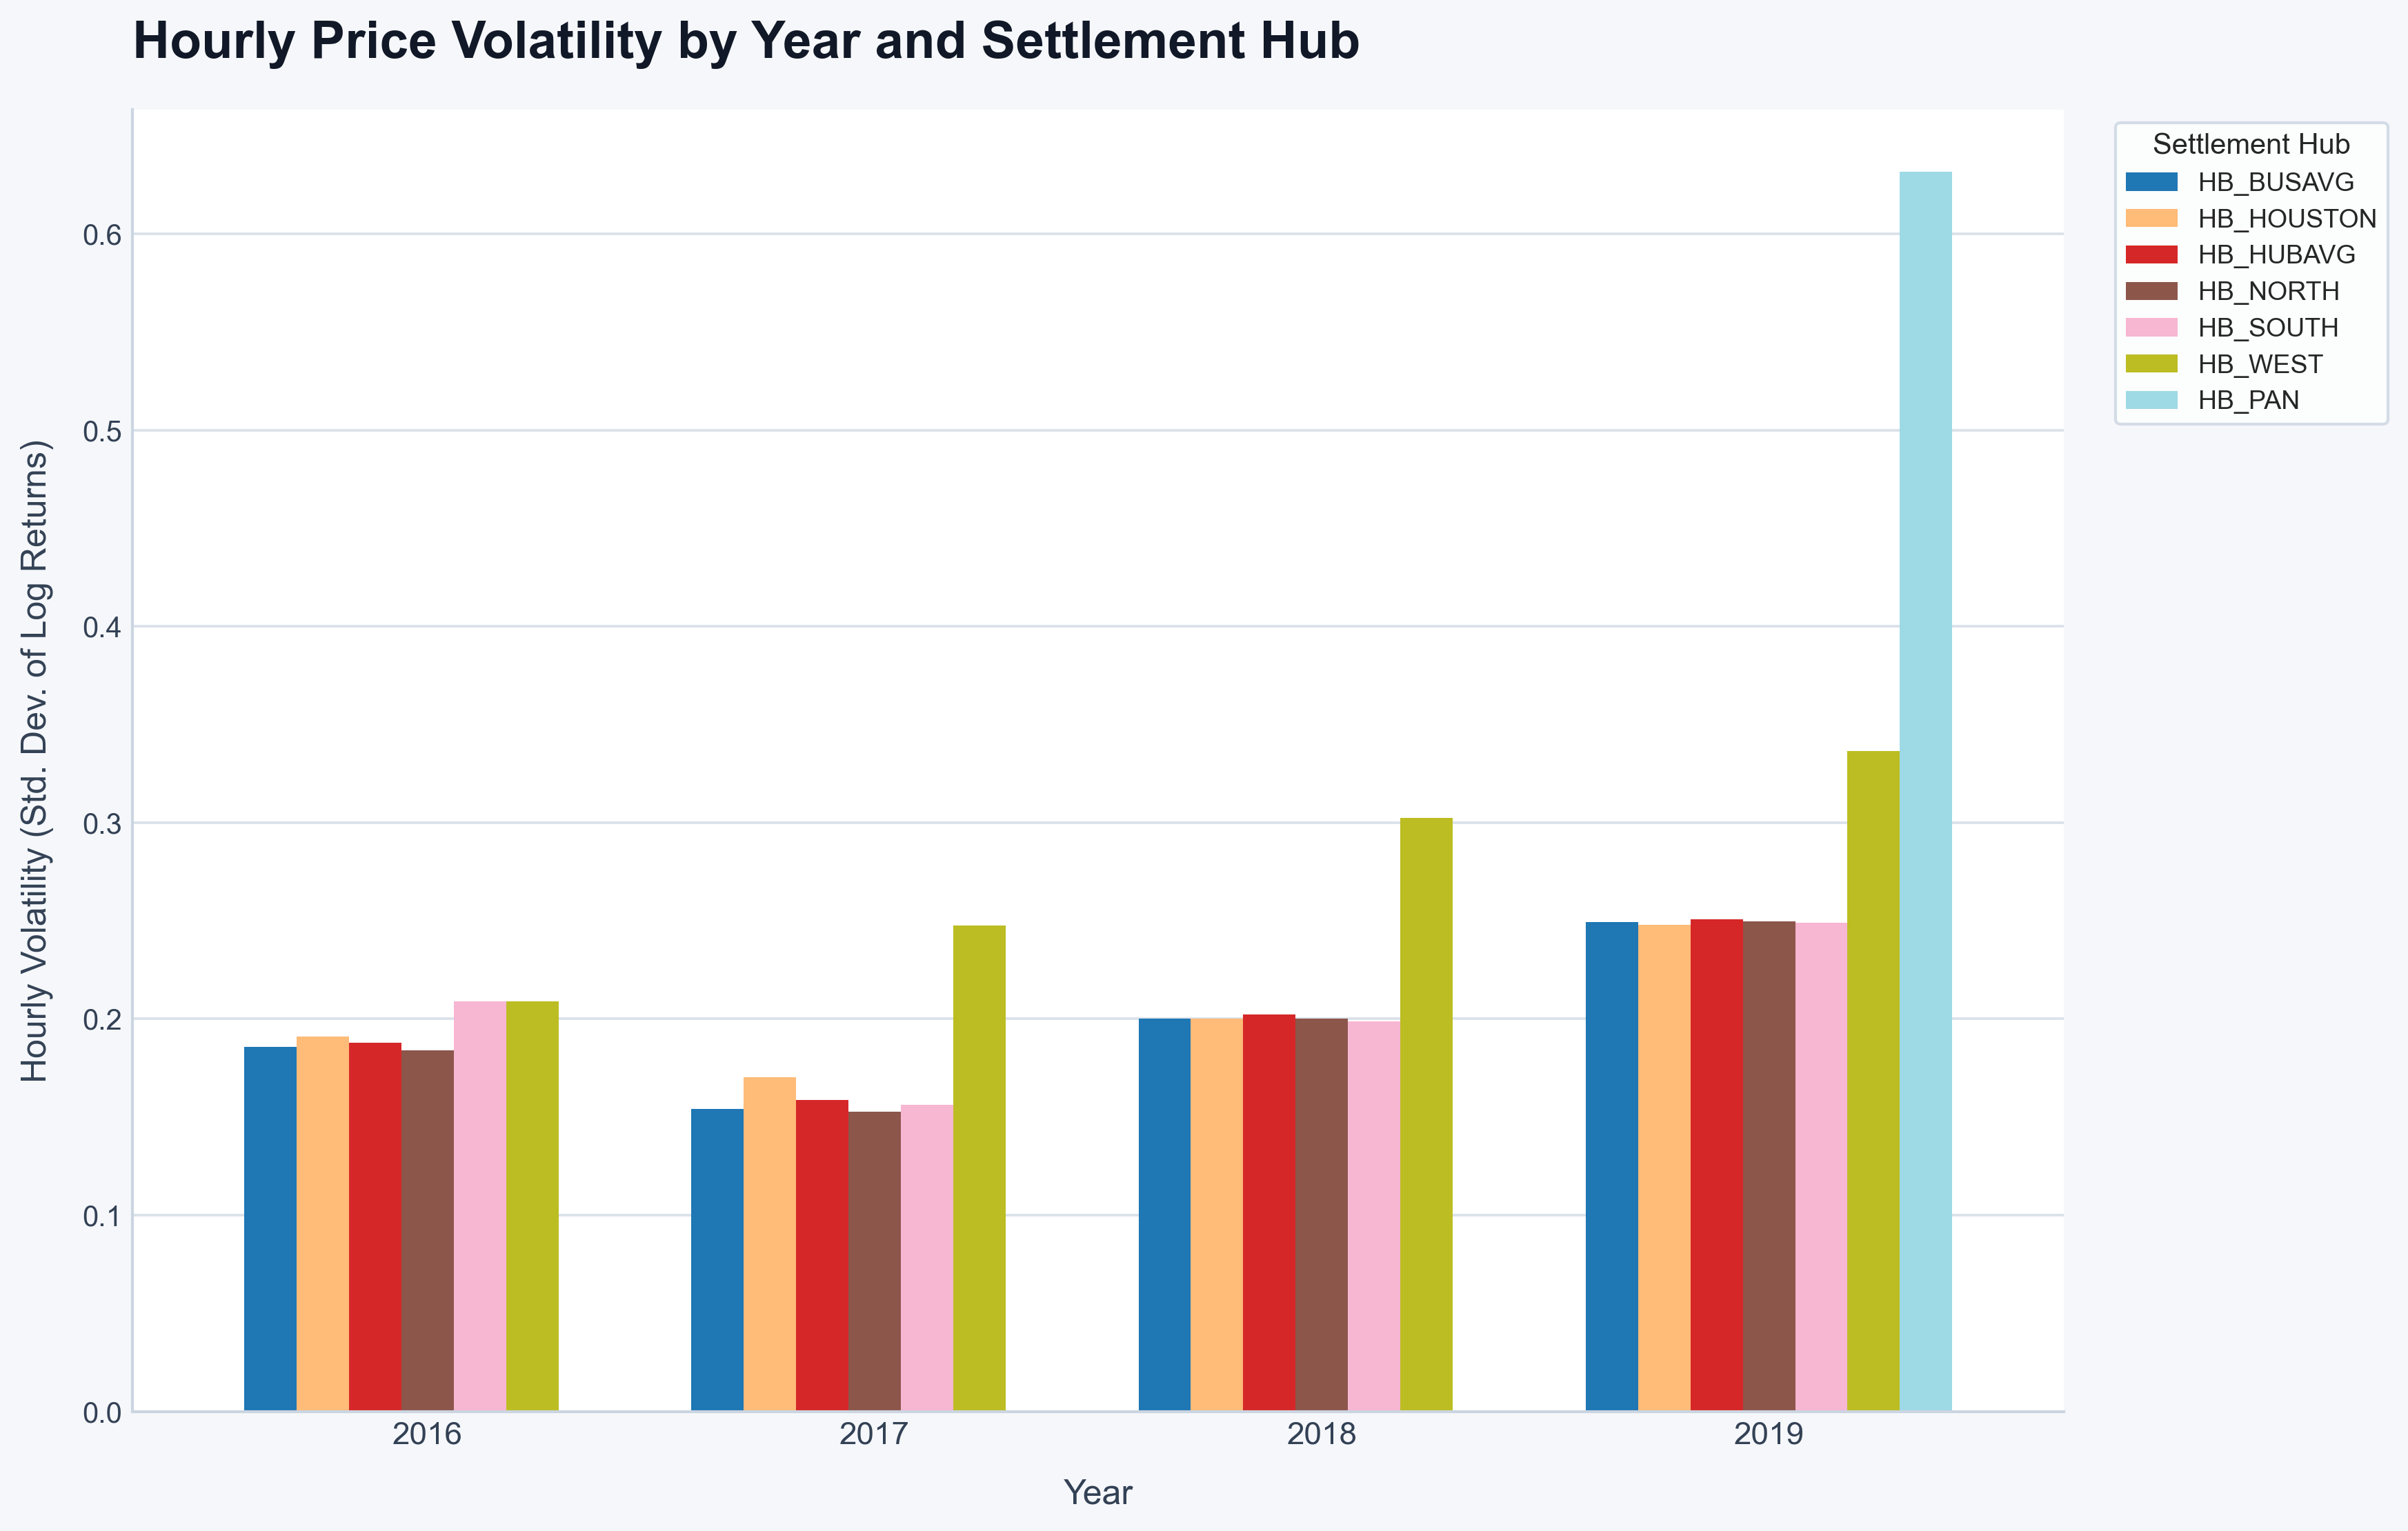

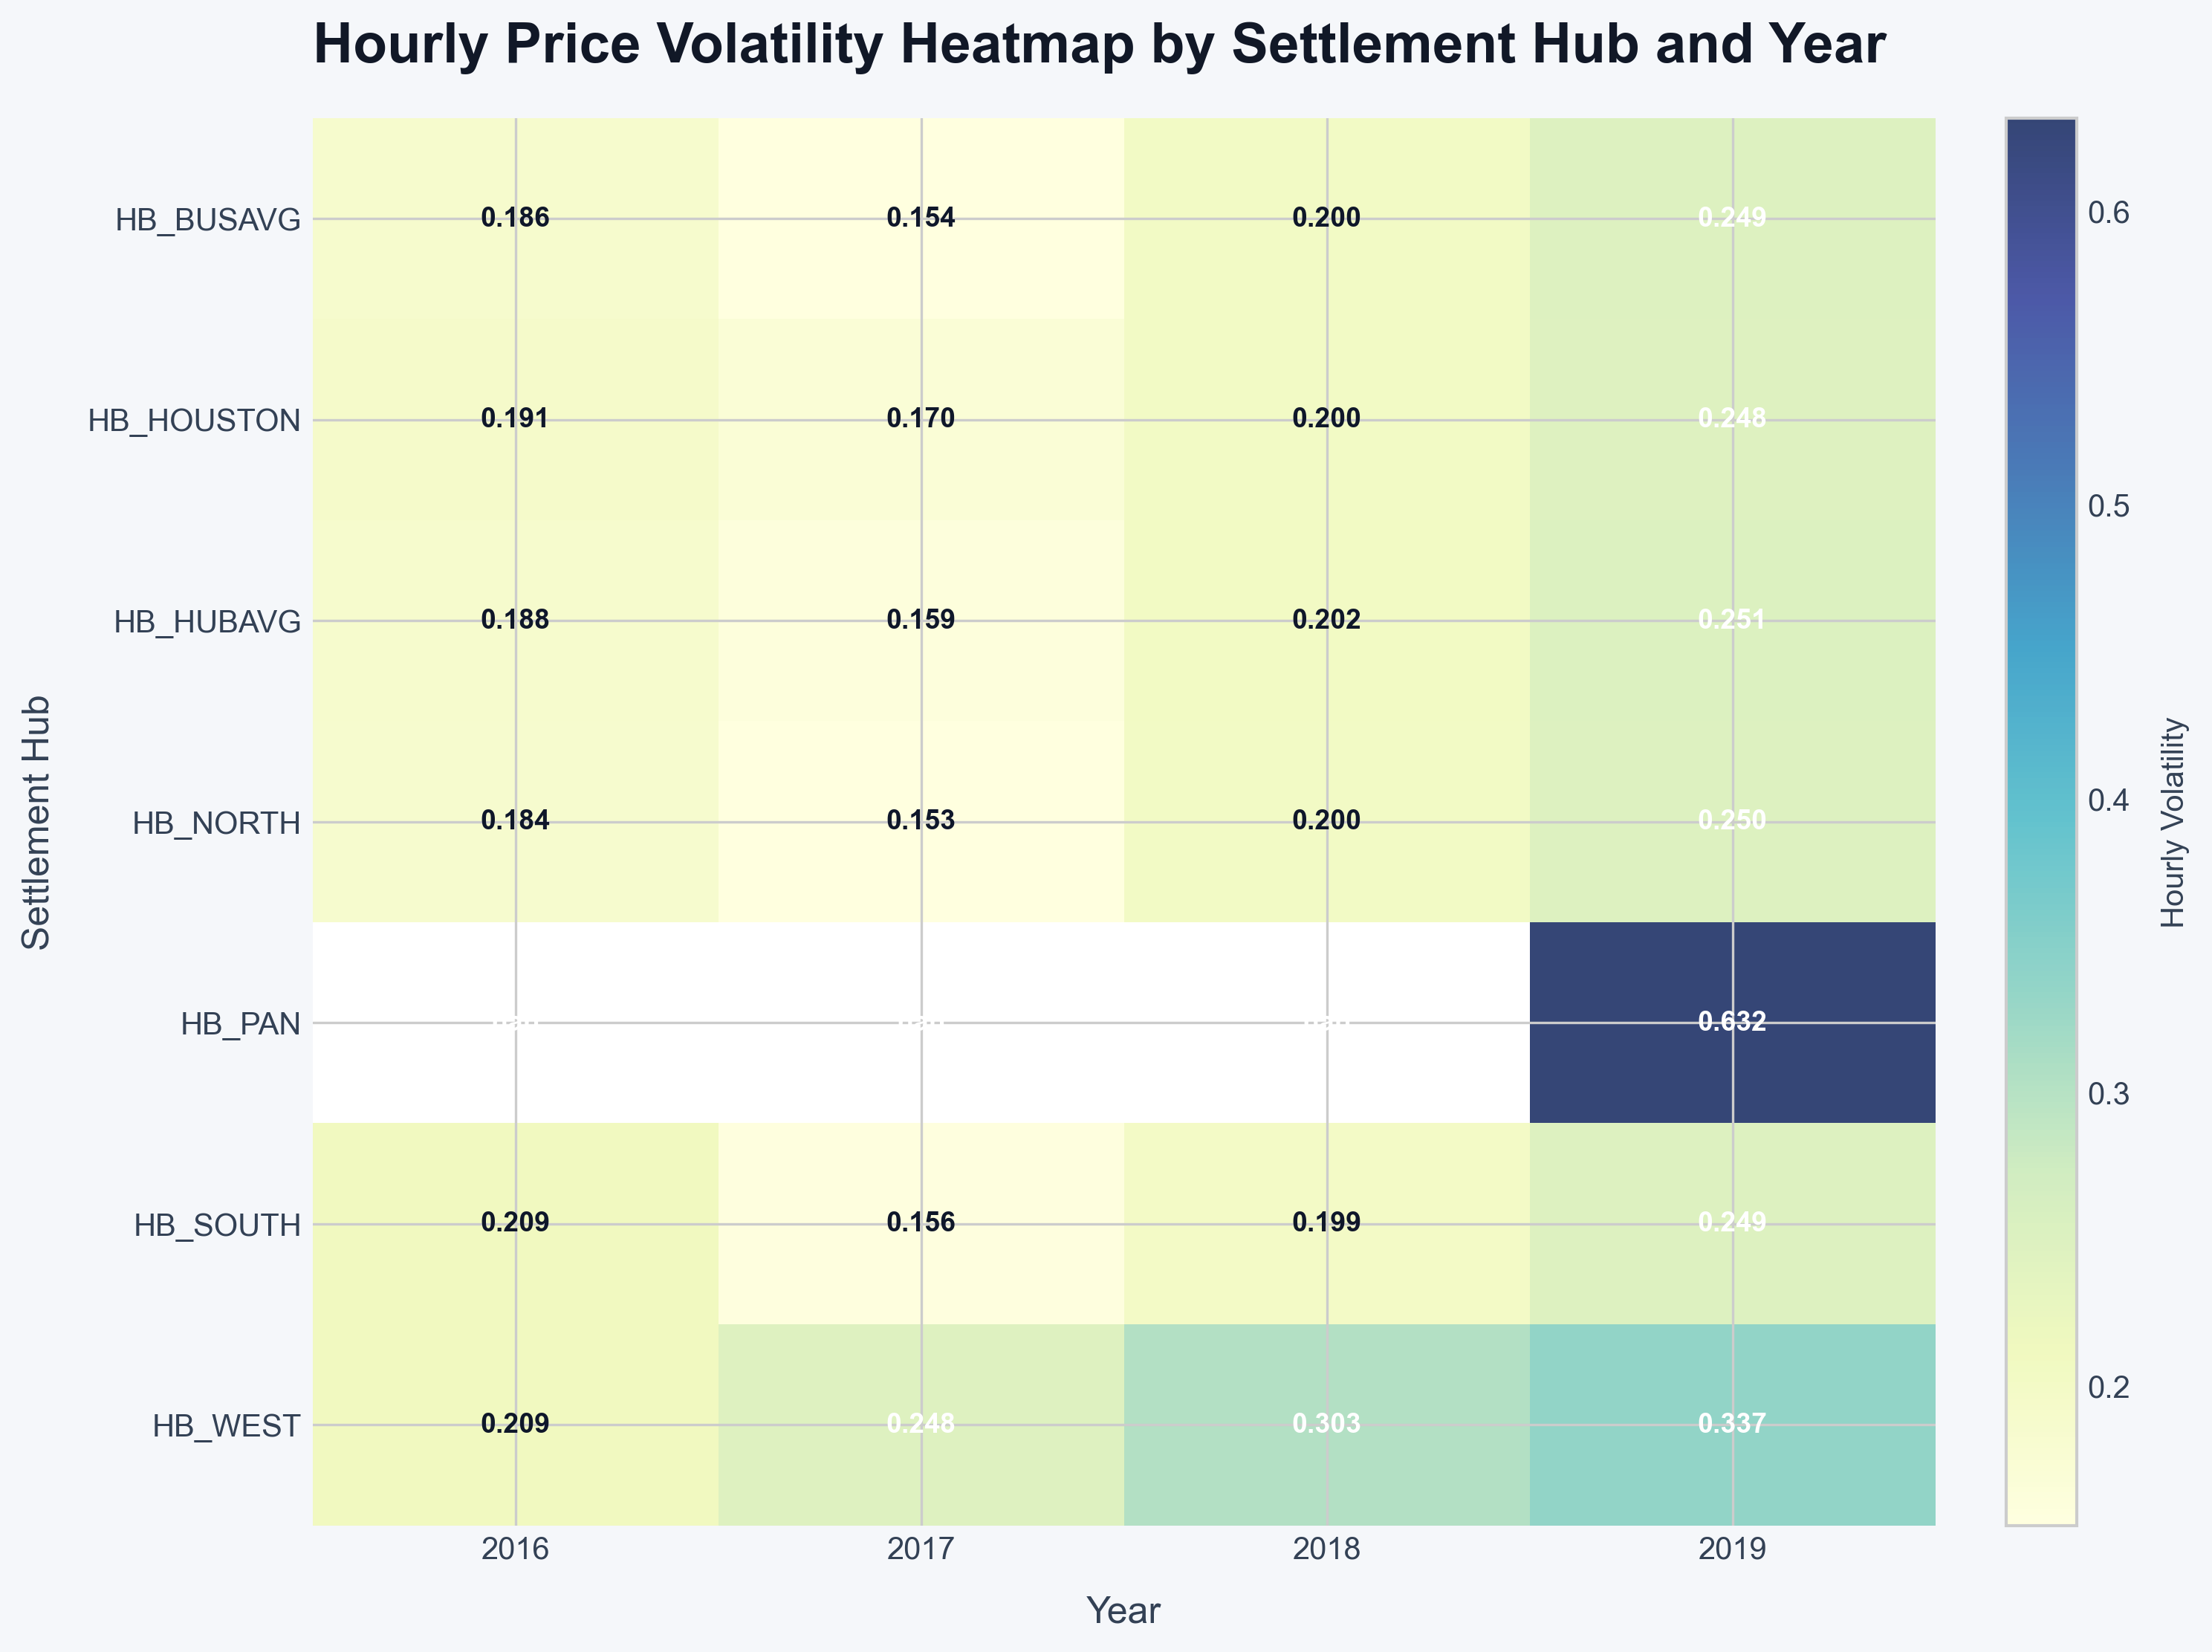

In [60]:
yearly_volatility_plot_paths = yearly_volatility_plots(volatility)
display(Image(filename=str(yearly_volatility_plot_paths['bar_chart'])))
display(Image(filename=str(yearly_volatility_plot_paths['heatmap'])))

#### Bonus – Hourly Shape Profile Computation 

In [61]:
profile_files, profile_check_df = compute_hourly_shape_profiles(combined_df)

### Bonus - Open-Ended Analysis

##### Comparing Hub and Load Zone Prices to Identify Basis Risk and Congestion Hotspots

**Analyze how closely settlement hub prices track their corresponding load zone prices and identify regions and periods where congestion creates significant price differences**.

- Hub and load zone prices were usually very similar, especially for Houston and North, with both moving closely together over time.

- The West region stood out because the gap between the hub price and load zone price was larger and happened more often than in the other regions.

- During several periods in 2018 and 2019, LZ_WEST was noticeably more expensive than HB_WEST, creating a large hub-to-load-zone spread.

- This suggests that HB_WEST may not always be a good indicator of actual load-zone prices, particularly during periods of congestion or market stress.

- The heatmap shows that most of the basis risk is concentrated in the West region, while Houston and North remain relatively stable.

- From a risk and hedging perspective, West ERCOT appears to have the greatest exposure to locational price differences, whereas Houston and North show much smaller and more predictable differences.

In [62]:
print("Hub/load-zone mapping used for basis analysis")
display(open_ended_tables['hub_load_zone_mapping'])

print("Unusually high congestion periods")
display(open_ended_tables['congestion_periods'][['MonthStart', 'SettlementHub', 'LoadZone', 'HubPrice', 'LoadZonePrice', 'LoadZoneMinusHubBasis', 'AbsBasis']])

display(Image(filename=str(open_ended_plot_paths['hub_vs_load_zone'])))
display(Image(filename=str(open_ended_plot_paths['basis_congestion'])))

Hub/load-zone mapping used for basis analysis


NameError: name 'open_ended_tables' is not defined